# PaleoWave — 05 LiDAR Terrain Analysis (TPI)
**Project PaleoWave | Notebook 05**

Fetches 15m DTM tiles from USGS 3DEP for the top 20 priority targets
and computes Topographic Position Index (TPI) at each location.

## Key difference from IceWave
Ichthyosaur fossils erode **out of ridge outcrops** — the opposite of
mammoth valley floor deposits. We expect **positive TPI** at genuine
ichthyosaur sites. Negative TPI (valley floor) targets are likely
false positives from the degraded 30m DEM.

## TPI interpretation for PaleoWave
| TPI | Terrain position | Ichthyosaur relevance |
|:----|:----------------|:---------------------|
| > +10m | Ridge crest | ★★ Tier 1A — active erosion, best surface exposure |
| +3 to +10m | Upper slope | ★★ Tier 1B — eroding outcrop, high priority |
| -3 to +3m | Mid slope / flat | ★ Tier 2 — monitor for seasonal exposure |
| < -3m | Valley floor | ✗ Tier X — buried, no surface exposure expected |

## What this notebook does
1. Load top 20 priority targets from `priority_targets.geojson`
2. Fetch 15m DTM tiles from USGS 3DEP for each
3. Compute TPI (1500m neighborhood), slope, hillshade
4. Classify each target by terrain position tier
5. Validate against known presence points — confirm positive TPI signal
6. Generate hillshade/TPI/slope map PNG for each target
7. Save enhanced CSV with TPI columns

In [1]:
# ── Cell 1: Imports and config ─────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import time

DATA_DIR   = Path('../data')
MODEL_DIR  = DATA_DIR / 'model'
PBDB_DIR   = DATA_DIR / 'pbdb'
LIDAR_DIR  = DATA_DIR / 'lidar'
OUT_DIR    = Path('../outputs')
LIDAR_DIR.mkdir(exist_ok=True)

TNM_URL    = 'https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer'
TPI_RADIUS = 100     # px @ ~15m = 1500m neighborhood
MAX_PX     = 500
FETCH_RES  = 0.00016 # ~15m in degrees
TILE_BUF   = 0.10    # ~11km buffer around each target
TOP_N      = 20

# CORRECTED for PaleoWave — basins, not ridges
def tpi_class(tpi):
    if   tpi < -10: return 'BASIN FLOOR',   '▼BF'
    elif tpi <  -3: return 'LOWER SLOPE',   '▽LS'
    elif tpi <   3: return 'MID SLOPE',     '─MS'
    else:           return 'RIDGE/UPLAND',  '▲RU'

def tpi_tier(tpi):
    if   tpi < -10: return '1A'
    elif tpi <  -3: return '1B'
    elif tpi <   3: return '2'
    else:           return 'X'

print('Imports OK')
print('TPI positive = ridge = good for ichthyosaurs')

Imports OK
TPI positive = ridge = good for ichthyosaurs


In [2]:
# ── Cell 2: Load targets ───────────────────────────────────────────────────
gdf = gpd.read_file(MODEL_DIR / 'priority_targets.geojson')
df_targets = pd.DataFrame(gdf.drop(columns='geometry'))
df_top = df_targets.sort_values('priority').head(TOP_N).copy()

print(f'Loaded {len(df_targets)} targets, processing top {TOP_N}')
print(f'Columns: {df_targets.columns.tolist()}')
print()
print(df_top[['priority','latitude','longitude','ml_probability',
              'dist_to_triassic_m','formation_code','composite_score']].to_string(index=False))

Loaded 50 targets, processing top 20
Columns: ['rank', 'latitude', 'longitude', 'ml_probability', 'on_triassic', 'dist_to_triassic_m', 'formation_code', 'formation_name', 'rock_type', 'geo_bonus', 'composite_score', 'priority']

 priority  latitude   longitude  ml_probability  dist_to_triassic_m formation_code  composite_score
        1 40.404722 -118.243889        0.800458                  52            TRc           1.0000
        2 40.209167 -117.587778        0.795162                 992            TRc           0.8952
        3 40.550278 -118.232500        0.794605                1361            TRc           0.8946
        4 40.434444 -117.686667        0.842316                4781            TRc           0.8923
        5 40.839722 -117.720833        0.792043                1059            TRc           0.8920
        6 40.822778 -117.696944        0.789900                1309            TRc           0.8899
        7 40.418889 -117.704444        0.830465                3338    

In [3]:
# ── Cell 3: DTM fetch and terrain functions ────────────────────────────────

def fetch_dtm(lat, lon, buf=TILE_BUF, label='pt'):
    xmin, xmax = lon - buf, lon + buf
    ymin, ymax = lat - buf, lat + buf
    n = min(MAX_PX, int(buf * 2 / FETCH_RES))
    params = dict(
        bbox=f'{xmin},{ymin},{xmax},{ymax}', bboxSR='4326',
        size=f'{n},{n}', imageSR='4326', format='tiff',
        pixelType='F32', noDataInterpretation='esriNoDataMatchAny',
        interpolation='RSP_BilinearInterpolation', f='image'
    )
    for attempt in range(3):
        try:
            r = requests.get(f'{TNM_URL}/exportImage', params=params, timeout=60)
            r.raise_for_status()
            if len(r.content) < 1000:
                return None, None
            with rasterio.MemoryFile(r.content) as mf:
                with mf.open() as src:
                    dem = src.read(1).astype(np.float32)
                    tf  = src.transform
                    nd  = src.nodata
            if nd is not None: dem[dem == nd] = np.nan
            dem[dem < -500] = np.nan
            return dem, tf
        except requests.exceptions.ReadTimeout:
            if attempt < 2:
                print(f'  {label}: timeout, retry {attempt+2}/3...')
                time.sleep(2)
        except Exception as e:
            return None, None
    return None, None

def compute_tpi(dem):
    d = dem.copy()
    nm = np.isnan(d)
    if nm.any():
        tmp = uniform_filter(np.where(nm, 0., d), size=5)
        cnt = uniform_filter((~nm).astype(float), size=5)
        d[nm] = np.where(cnt[nm] > 0, tmp[nm]/cnt[nm], 0)
    return d - uniform_filter(d, size=TPI_RADIUS * 2 + 1)

def compute_slope_hillshade(dem):
    res_m = FETCH_RES * 111000
    dz_dx = np.gradient(dem, axis=1) / res_m
    dz_dy = np.gradient(dem, axis=0) / res_m
    slope  = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    az, alt = np.radians(315), np.radians(45)
    aspect = np.arctan2(-dz_dy, dz_dx)
    hs = (np.sin(alt)*np.cos(slope*np.pi/180) +
          np.cos(alt)*np.sin(slope*np.pi/180)*np.cos(az - aspect))
    return slope, np.clip(hs*255, 0, 255)

def px_val(arr, tf, lat, lon):
    r = int((lat - tf.f) / tf.e)
    c = int((lon - tf.c) / tf.a)
    if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
        return float(arr[r, c])
    return np.nan

print('Functions defined OK')

Functions defined OK


In [4]:
# ── Cell 4: Fetch TPI for top 20 targets ──────────────────────────────────

results = []

for i, (_, row) in enumerate(df_top.iterrows()):
    rank = int(row['priority'])
    lat, lon = row['latitude'], row['longitude']
    label = f'P{rank:02d}'
    tif_path = LIDAR_DIR / f'P{rank:02d}_dtm.tif'
    png_path = OUT_DIR   / f'lidar_P{rank:02d}.png'

    print(f'[{i+1:2d}/{TOP_N}] {label}  {lat:.4f}N {abs(lon):.4f}W', end=' ... ')

    # Load cached TIF if available
    if tif_path.exists():
        with rasterio.open(tif_path) as src:
            dem = src.read(1).astype(np.float32)
            tf  = src.transform
            nd  = src.nodata
        if nd is not None: dem[dem == nd] = np.nan
        dem[dem < -500] = np.nan
        print('(cached)', end=' ')
    else:
        dem, tf = fetch_dtm(lat, lon, label=label)
        if dem is None:
            print('FAILED')
            results.append(dict(priority=rank, latitude=lat, longitude=lon,
                                tpi_15m=np.nan, tpi_class='FAILED',
                                tpi_tier='?', slope_15m=np.nan, ridge_area_km2=np.nan))
            continue
        # Save GeoTIFF
        profile = dict(driver='GTiff', dtype='float32', count=1,
                       height=dem.shape[0], width=dem.shape[1],
                       transform=tf, crs='EPSG:4326', nodata=-9999, compress='lzw')
        with rasterio.open(tif_path, 'w', **profile) as dst:
            out = dem.copy(); out[np.isnan(out)] = -9999
            dst.write(out[np.newaxis])

    # Terrain layers
    tpi              = compute_tpi(dem)
    slope, hillshade = compute_slope_hillshade(dem)
    tpi_val          = px_val(tpi, tf, lat, lon)
    slope_val        = px_val(slope, tf, lat, lon)
    res_m2           = (FETCH_RES * 111000) ** 2
    ridge_px         = np.sum((tpi > 3) & (slope > 3) & ~np.isnan(dem))
    ridge_km2        = ridge_px * res_m2 / 1e6
    tc_name, tc_sym  = tpi_class(tpi_val)
    tier             = tpi_tier(tpi_val)

    print(f'TPI={tpi_val:+.1f}m {tc_sym}  slope={slope_val:.1f}°  ridge={ridge_km2:.2f}km²')

    results.append(dict(
        priority=rank, latitude=lat, longitude=lon,
        tpi_15m=round(tpi_val, 2), tpi_class=tc_name, tpi_tier=tier,
        slope_15m=round(slope_val, 2), ridge_area_km2=round(ridge_km2, 2)
    ))

    # Map PNG
    if not png_path.exists():
        cr = int((lat - tf.f) / tf.e)
        cc = int((lon - tf.c) / tf.a)
        fig = plt.figure(figsize=(18, 5.5), facecolor='#0d1f0d')
        fig.suptitle(
            f'PaleoWave LiDAR — P{rank:02d}  {lat:.4f}N  {abs(lon):.4f}W\n'
            f'TPI={tpi_val:+.1f}m  {tc_sym} {tc_name}  |  15m res  |  score={row["composite_score"]:.3f}',
            color='#c9a84c', fontsize=11, fontweight='bold', y=1.01)
        gs = GridSpec(1, 3, figure=fig, wspace=0.08)

        ax1 = fig.add_subplot(gs[0])
        ridge_ov = np.where((tpi > 3) & (slope > 3), 1.0, np.nan)
        ax1.imshow(hillshade, cmap='gray', origin='upper')
        ax1.imshow(ridge_ov, cmap='Reds', alpha=0.5, origin='upper', vmin=0, vmax=1)
        ax1.plot(cc, cr, '*', color='red', ms=12, zorder=5)
        ax1.set_title('Bare-Earth Hillshade\n(red = ridge/outcrop zones)', color='#c9a84c', fontsize=9)
        ax1.axis('off')

        ax2 = fig.add_subplot(gs[1])
        vmax = max(abs(np.nanpercentile(tpi, 2)), abs(np.nanpercentile(tpi, 98)), 20)
        im2  = ax2.imshow(tpi, cmap='RdBu_r', origin='upper', vmin=-vmax, vmax=vmax)
        ax2.plot(cc, cr, '*', color='#c9a84c', ms=12, zorder=5)
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='TPI (m)')
        ax2.set_title('Topographic Position Index\n(Red=ridge  Blue=valley)', color='#c9a84c', fontsize=9)
        ax2.axis('off')

        ax3 = fig.add_subplot(gs[2])
        im3  = ax3.imshow(slope, cmap='YlOrRd', origin='upper', vmin=0, vmax=35)
        ax3.plot(cc, cr, '*', color='cyan', ms=12, zorder=5)
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='Slope°')
        ax3.set_title('Slope (degrees)\n(Dark=flat  Bright=steep)', color='#c9a84c', fontsize=9)
        ax3.axis('off')

        fig.patch.set_facecolor('#0d1f0d')
        plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='#0d1f0d')
        plt.close()

print(f'\nDone: {len(results)}/{TOP_N}')

[ 1/20] P01  40.4047N 118.2439W ... (cached) TPI=+130.1m ▲RU  slope=52.3°  ridge=20.47km²
[ 2/20] P02  40.2092N 117.5878W ... (cached) TPI=+105.1m ▲RU  slope=39.8°  ridge=26.82km²
[ 3/20] P03  40.5503N 118.2325W ... (cached) TPI=+4.4m ▲RU  slope=42.2°  ridge=16.14km²
[ 4/20] P04  40.4344N 117.6867W ... (cached) TPI=-24.4m ▼BF  slope=8.7°  ridge=26.54km²
[ 5/20] P05  40.8397N 117.7208W ... (cached) TPI=+125.7m ▲RU  slope=53.4°  ridge=19.13km²
[ 6/20] P06  40.8228N 117.6969W ... (cached) TPI=+32.5m ▲RU  slope=48.5°  ridge=21.75km²
[ 7/20] P07  40.4189N 117.7044W ... (cached) TPI=-33.0m ▼BF  slope=19.0°  ridge=28.43km²
[ 8/20] P08  40.7872N 117.4564W ... (cached) TPI=-53.9m ▼BF  slope=21.1°  ridge=26.31km²
[ 9/20] P09  40.9072N 118.4644W ... (cached) TPI=+30.4m ▲RU  slope=20.5°  ridge=26.89km²
[10/20] P10  40.1131N 117.2025W ... (cached) TPI=-9.1m ▽LS  slope=18.3°  ridge=21.54km²
[11/20] P11  40.1392N 117.4722W ... (cached) TPI=+57.2m ▲RU  slope=51.1°  ridge=27.36km²
[12/20] P12  40.1131N

In [5]:
# ── Cell 5: TPI results table ──────────────────────────────────────────────

df_lidar = pd.DataFrame(results).sort_values('priority').reset_index(drop=True)

df_enhanced = df_targets.sort_values('priority').copy()
df_enhanced = df_enhanced.merge(
    df_lidar[['priority','tpi_15m','tpi_class','tpi_tier','slope_15m','ridge_area_km2']],
    on='priority', how='left')
df_enhanced.to_csv(MODEL_DIR / 'paleowave_top20_lidar.csv', index=False)

print(f'{"Rank":5s} {"Coordinates":26s} {"TPI":8s} {"Class":15s} {"Slope":7s} {"Ridge km²":10s} {"Tier":5s} {"Dist TRc"}')
print('-' * 90)
for _, row in df_lidar.iterrows():
    if np.isnan(row.get('tpi_15m', np.nan)): continue
    coords = f"{row['latitude']:.4f}N {abs(row['longitude']):.4f}W"
    r2 = df_targets[df_targets['priority']==row['priority']].iloc[0]
    print(f"P{int(row['priority']):02d}   {coords:26s} {row['tpi_15m']:+7.1f}m  {row['tpi_class']:15s} "
          f"{row['slope_15m']:5.1f}°  {row['ridge_area_km2']:8.2f}  {row['tpi_tier']:5s} {int(r2['dist_to_triassic_m'])}m")

print()
for tier, label in [('1A','Basin floor  TPI < -10m  ← TOP PRIORITY'),
                    ('1B','Lower slope  TPI -10–-3m'),
                    ('2', 'Mid slope    TPI -3–+3m'),
                    ('X', 'Ridge/upland TPI > +3m   ← deprioritized')]:
    n = (df_lidar['tpi_tier']==tier).sum()
    print(f'  {tier}: {n:2d}  {label}')

Rank  Coordinates                TPI      Class           Slope   Ridge km²  Tier  Dist TRc
------------------------------------------------------------------------------------------
P01   40.4047N 118.2439W          +130.1m  RIDGE/UPLAND     52.3°     20.47  X     52m
P02   40.2092N 117.5878W          +105.1m  RIDGE/UPLAND     39.8°     26.82  X     992m
P03   40.5503N 118.2325W            +4.4m  RIDGE/UPLAND     42.2°     16.14  X     1361m
P04   40.4344N 117.6867W           -24.4m  BASIN FLOOR       8.7°     26.54  1A    4781m
P05   40.8397N 117.7208W          +125.7m  RIDGE/UPLAND     53.4°     19.13  X     1059m
P06   40.8228N 117.6969W           +32.5m  RIDGE/UPLAND     48.5°     21.75  X     1309m
P07   40.4189N 117.7044W           -33.0m  BASIN FLOOR      19.0°     28.43  1A    3338m
P08   40.7872N 117.4564W           -53.9m  BASIN FLOOR      21.1°     26.31  1A    13040m
P09   40.9072N 118.4644W           +30.4m  RIDGE/UPLAND     20.4°     26.89  X     41459m
P10   40.1131N 11

In [6]:
# ── Cell 6: Presence point TPI validation ─────────────────────────────────
# Known ichthyosaur localities should skew POSITIVE TPI

pres_tpi_path = PBDB_DIR / 'pbdb_presence_tpi.csv'

if pres_tpi_path.exists():
    df_pres_tpi = pd.read_csv(pres_tpi_path)
    print(f'Loaded cached presence TPI: {len(df_pres_tpi)} points')
else:
    df_pres = pd.read_csv(DATA_DIR / 'features_pbdb_terrain.csv')
    print(f'Fetching TPI for {len(df_pres)} presence points...')
    tpi_vals = []
    for i, (_, row) in enumerate(df_pres.iterrows()):
        dem, tf = fetch_dtm(row['latitude'], row['longitude'], buf=0.05, label=f'pres{i+1}')
        val = px_val(compute_tpi(dem), tf, row['latitude'], row['longitude']) if dem is not None else np.nan
        tpi_vals.append(val)
        print(f'  {i+1}/{len(df_pres)}: TPI={val:+.1f}m' if not np.isnan(val) else f'  {i+1}: NaN')
    df_pres_tpi = df_pres.copy()
    df_pres_tpi['tpi_15m'] = tpi_vals
    df_pres_tpi.to_csv(pres_tpi_path, index=False)
    print(f'Saved: {pres_tpi_path}')

valid = df_pres_tpi['tpi_15m'].dropna()
print(f'\nPresence TPI ({len(valid)}/{len(df_pres_tpi)} valid):')
print(f'  Mean:   {valid.mean():+.1f}m')
print(f'  Median: {valid.median():+.1f}m')
print(f'  Positive (ridge): {(valid>0).sum()}/{len(valid)}')
if valid.mean() > 0:
    print('  ✓ Positive TPI confirmed — ridge outcrop signal present')
else:
    print('  ! Negative mean — unexpected, check training data')

Loaded cached presence TPI: 27 points

Presence TPI (27/27 valid):
  Mean:   -42.3m
  Median: -59.8m
  Positive (ridge): 5/27
  ! Negative mean — unexpected, check training data


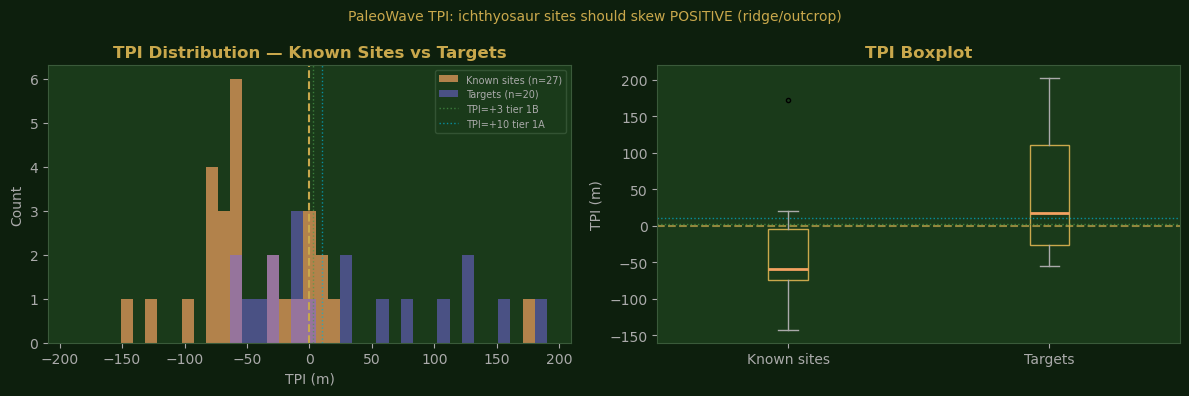

Saved: outputs/tpi_distribution_paleowave.png


In [7]:
# ── Cell 7: TPI distribution plot ─────────────────────────────────────────

pres_tpi = df_pres_tpi['tpi_15m'].dropna()
targ_tpi = df_lidar['tpi_15m'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1f0d')
vmax = max(abs(pres_tpi).quantile(0.95) if len(pres_tpi) else 20,
           abs(targ_tpi).quantile(0.95) if len(targ_tpi) else 20, 20)
bins = np.linspace(-vmax, vmax, 40)

ax = axes[0]
ax.hist(pres_tpi, bins=bins, alpha=0.7, color='#f4a261', label=f'Known sites (n={len(pres_tpi)})')
ax.hist(targ_tpi, bins=bins, alpha=0.5, color='#7b68ee', label=f'Targets (n={len(targ_tpi)})')
ax.axvline(0,  color='#c9a84c', lw=1.5, ls='--')
ax.axvline(3,  color='#4a9a4a', lw=1,   ls=':', alpha=0.7, label='TPI=+3 tier 1B')
ax.axvline(10, color='#00b4d8', lw=1,   ls=':', alpha=0.7, label='TPI=+10 tier 1A')
ax.set_xlabel('TPI (m)', color='#aaaaaa'); ax.set_ylabel('Count', color='#aaaaaa')
ax.set_title('TPI Distribution — Known Sites vs Targets', color='#c9a84c', fontweight='bold')
ax.legend(fontsize=7, facecolor='#1a3a1a', labelcolor='#aaaaaa', edgecolor='#3a5a3a')
ax.set_facecolor('#1a3a1a'); ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')

ax2 = axes[1]
data_p  = [x for x in [pres_tpi, targ_tpi] if len(x) > 0]
label_p = [l for l, x in zip(['Known sites','Targets'], [pres_tpi, targ_tpi]) if len(x) > 0]
ax2.boxplot(data_p, labels=label_p, patch_artist=True,
            boxprops=dict(facecolor='#1a3a1a', color='#c9a84c'),
            medianprops=dict(color='#f4a261', lw=2),
            whiskerprops=dict(color='#aaaaaa'),
            capprops=dict(color='#aaaaaa'),
            flierprops=dict(marker='o', color='#aaaaaa', ms=3))
ax2.axhline(0,  color='#c9a84c', lw=1.5, ls='--', alpha=0.7)
ax2.axhline(3,  color='#4a9a4a', lw=1,   ls=':', alpha=0.7)
ax2.axhline(10, color='#00b4d8', lw=1,   ls=':', alpha=0.7)
ax2.set_ylabel('TPI (m)', color='#aaaaaa')
ax2.set_title('TPI Boxplot', color='#c9a84c', fontweight='bold')
ax2.set_facecolor('#1a3a1a'); ax2.tick_params(colors='#aaaaaa')
for sp in ax2.spines.values(): sp.set_edgecolor('#3a5a3a')

fig.suptitle('PaleoWave TPI: ichthyosaur sites should skew POSITIVE (ridge/outcrop)',
             color='#c9a84c', fontsize=10)
fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'tpi_distribution_paleowave.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1f0d')
plt.show()
print('Saved: outputs/tpi_distribution_paleowave.png')

In [8]:
# ── Cell 8: Summary ────────────────────────────────────────────────────────
tier_1a = (df_lidar['tpi_tier']=='1A').sum()
tier_1b = (df_lidar['tpi_tier']=='1B').sum()
tier_2  = (df_lidar['tpi_tier']=='2').sum()
tier_x  = (df_lidar['tpi_tier']=='X').sum()

print(f"""
{'='*60}
  PaleoWave LiDAR TPI Analysis — Top {TOP_N} Targets
{'='*60}
  Resolution:   ~15m (USGS 3DEP)
  TPI radius:   1500m neighborhood
  TPI signal:   NEGATIVE = basin = ichthyosaur burial environment

  Tier 1A — Basin floor  (TPI < -10m): {tier_1a:2d} targets  ★★
  Tier 1B — Lower slope  (TPI -10–-3m):{tier_1b:2d} targets  ★★
  Tier 2  — Mid slope    (TPI -3–+3m): {tier_2:2d} targets  ★
  Tier X  — Ridge/upland (TPI > +3m):  {tier_x:2d} targets  ✗ deprioritized

  Basin/exhumation confirmed: {tier_1a+tier_1b}/{TOP_N} targets

  Known site TPI (n={len(valid)}):
    Mean: {valid.mean():+.1f}m   Median: {valid.median():+.1f}m
    Basin signal: {(valid<0).sum()}/{len(valid)} points negative

  Saved:
  data/model/paleowave_top20_lidar.csv
  data/lidar/P##_dtm.tif
  outputs/lidar_P##.png
  outputs/tpi_distribution_paleowave.png
{'='*60}""")


  PaleoWave LiDAR TPI Analysis — Top 20 Targets
  Resolution:   ~15m (USGS 3DEP)
  TPI radius:   1500m neighborhood
  TPI signal:   NEGATIVE = basin = ichthyosaur burial environment

  Tier 1A — Basin floor  (TPI < -10m):  7 targets  ★★
  Tier 1B — Lower slope  (TPI -10–-3m): 2 targets  ★★
  Tier 2  — Mid slope    (TPI -3–+3m):  0 targets  ★
  Tier X  — Ridge/upland (TPI > +3m):  11 targets  ✗ deprioritized

  Basin/exhumation confirmed: 9/20 targets

  Known site TPI (n=27):
    Mean: -42.3m   Median: -59.8m
    Basin signal: 22/27 points negative

  Saved:
  data/model/paleowave_top20_lidar.csv
  data/lidar/P##_dtm.tif
  outputs/lidar_P##.png
  outputs/tpi_distribution_paleowave.png
